In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Cell1 导入所需库
# 1. 安装必要的中文分词库（如果 Colab 没自带）
!pip install jieba -q

# 2. 导入基础数据处理库
import pandas as pd
import numpy as np
import joblib

# 3. 导入机器学习相关库
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA  # 用于降维，方便画图看聚类效果

# 4. 导入绘图库
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图字体，防止中文乱码（Colab环境下）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import matplotlib.pyplot as plt

# 1. 设置中文字体（以黑体为例）
plt.rcParams['font.sans-serif'] = ['SimHei']

# 2. 解决坐标轴负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

# 如果你是 Mac 系统，请使用下面这行：
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

print("✅ 环境配置完成，所有库已成功导入！")

✅ 环境配置完成，所有库已成功导入！


In [ ]:
#读取原raw data
# 2. 定义文件路径
file_path = '/content/drive/MyDrive/Colab Notebooks/5572 flower/poems_dataset_merged_done.xlsx'

# 3. 读取 Excel
try:
    if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)

    print(f"✅ 成功读取文件！数据量：{len(df)} 行")

    # 检查你提到的列是否存在
    required_columns = ['poem', 'interpretation']
    for col in required_columns:
        if col not in df.columns:
            print(f"⚠️ 警告：列名 '{col}' 未找到，请检查 Excel 表头！")
            print(f"当前表格列名包含: {df.columns.tolist()}")

    display(df.head()) # 预览前5行
except Exception as e:
    print(f"❌ 读取失败，请检查路径是否正确。错误信息: {e}")

✅ 成功读取文件！数据量：1075 行


,ID,month,month_number,flower,poem_title,time,author,poem,interpretation
0,1,正月,1,梅花,早 梅,南朝梁,何逊,兔园标物序， 惊时最是梅。\n衔霜当路发， 映雪拟寒开。\n枝横却月观， 花绕凌风台。\n朝...,这是文人专咏梅花的诗作中时代较早的-首，极负盛名。\n初春的·天，建安王园林的梅花突然冒雪盛...
1,2,正月,1,梅花,咏梅花,南朝梁,鲍泉,可怜阶下梅， 飘荡逐风回。\n度帘拂罗幌， 萦窗落梳台。\n乍随纤手去， 还因插鬓来。\n客...,这首《咏梅花》，从梅花的飘零写到人生的飘零，情调是凄婉的。起首“可怜”二字，即为全诗定下了感...
2,3,正月,1,梅花,梅 花,北朝周,庾信,当年腊月半， 已觉梅花阑。\n不信今春晚， 俱来雪里看。\n树动悬冰落， 枝高出手寒。\n早...,庾信原是南朝梁著名的宫体诗人，出使西魏，正值西魏灭梁，被迫留在北朝，历仕西魏、北周。他的后期...
3,4,正月,1,梅花,梅花落,南朝宋,鲍照,中庭杂树多，偏为梅咨嗟。“问君何独然？”“念其霜中能作花，露中能作实。摇荡春风媚春日，念尔零...,这是南北朝时期诗人鲍照的一首非常著名的乐府诗。《梅花落>是汉代横吹曲目之一。郭茂倩<乐府诗集...
4,5,正月,1,梅花,和秦太虚梅花,宋,苏轼,西湖居士骨应槁， 只有此诗君压倒。\n东坡先生心已灰， 为爱君诗被花恼。\n多情立马待黄昏，...,"东坡七古气势轩昂，若风檣阵马，一片神行，最能体现其“万斛泉源，不择地而出""，“滔滔汨汨，虽一..."


## 1.2 使用stop词字典过滤

In [ ]:
import jieba
#cell3: 分词+过滤虚词+stop字典
# 1. 定义虚词/停用词列表 (Stopwords)
# 你可以根据实际效果随时在这个列表中添加你不想看到的词
stopwords = [

#古汉语虚词
'之', '乎', '者', '也', '矣', '焉', '哉', '所', '于', '以', '而', '则', '其', '乃', '与', '为', '且', '夫', '若',

#现代汉语虚词/常用词
'的', '了', '在', '是', '有', '我', '你', '他', '她', '它', '们', '这', '那', '就', '都', '而', '及', '并', '与',
'一个', '这种', '那个', '意思', '表达', '诗人', '描写', '作者', '诗中', '内容', '我们', '进行', '已经', '可以',

#新增停用词
'诗人', '一种', '花儿', '花','这儿', '那儿', '作者', '诗词', '词人', '对比', '一看', '怎样', '何解', '致使', '议论性',
'正是', '手法', '苏轼', '苏诗歌', '李白诗', '苏东坡', '烘托出', '理应', '耗地力', '连在一起', '气质', '陶渊明','作品','形象','写',
 '又', '中', '《', '诗', '和', '人', '不', ')', '》', '>', '；', '却', '对', '上', '但', '来', '着', '地', '说', '将', '从',
 '出', '把', '用', '使', '更', '得', '到', '字', '一', '<', '-', '便', '·', '后', '时', '即','已', '下', '呢', '此', '咏',
 '谁', '被', '去', '能', '很', '词', '看', '多', '由', '亦', '可', '还', '句', '既','指', '如', '见', '才', '给', '无',
 '作品', '形象','花','前','开','作','曾','虽','或','要','故','仍','里','正','小','会','好','相','处','红','皆','吗','只',
 '这首','这里','两句','表现','自己','二句','不是','人们','写出','如此','没有','这样','这是','然而','似乎','因为','所以',
 '而是','十分','生活','画面','之情','之中','不同','比喻','显得','描绘','形容','读者','四句','那么','此诗','因此','环境','就是','色彩','一首','不能','心理','开头',
 '—','过','向','一样','一片','象','等','--','人','有',
 '月','年','虽然','起','同时','因','只有','最后','似','一句','日','个','比','但是','看到','吧','再','当','三句','可见','一般','片','只是','上片','道','诗句','于是','还是','首句','其中','而且','事','吹','自','让','由于','不仅'


]
stopwords = [str(s).strip() for s in stopwords]

# 2. 处理缺失值
df['poem'] = df['poem'].fillna('')
df['interpretation'] = df['interpretation'].fillna('')

# 3. 构造三种实验文本
df['text_1_poem'] = df['poem']
df['text_2_interp'] = df['interpretation']
df['text_3_combined'] = df['poem'] + " " + df['interpretation']

# 4. 定义基于停用词表的分词函数

import re

def chinese_tokenizer_with_stopwords(text):
    if not isinstance(text, str):
        return ""

    # 1. 预处理：过滤掉绝大部分标点符号和特殊字符
    # 这个正则表达式会匹配：[中文标点] | [英文标点] | [换行符/空白符]
    # 如果你想保留特定的标点（比如问号），可以在中括号内排除它
    punctuation_pattern = r"[\s+\.\!\/_,$%^*(+\"\']+|[+——！，。？、~@＃￥％……＆*（）：“”‘’]+"
    text = re.sub(punctuation_pattern, " ", text)

    # 2. 使用 jieba 分词
    words = jieba.lcut(text)

# 在这里强制 strip()，确保过滤时完全匹配
    refined_words = []
    for w in words:
        clean_w = w.strip()
        # 核心逻辑：如果干净的词不在停用词表里，且长度大于0，才保留
        if clean_w and clean_w not in stopwords:
            refined_words.append(clean_w)

    return " ".join(refined_words)

# 5. 执行分词
print("正在执行精准停用词过滤分词...")
df['cut_poem'] = df['text_1_poem'].apply(chinese_tokenizer_with_stopwords)
df['cut_interp'] = df['text_2_interp'].apply(chinese_tokenizer_with_stopwords)
df['cut_combined'] = df['text_3_combined'].apply(chinese_tokenizer_with_stopwords)

save_path = '/content/drive/MyDrive/poem_tokenized_results.csv'
df.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"✅ 分词结果已成功保存至 Drive: {save_path}")

# 显示前5行，重点观察分词后是否还含有“之”、“的”等词
display(df[['cut_poem', 'cut_interp', 'cut_combined']].head())



/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...


正在执行精准停用词过滤分词...


Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.610 seconds.
DEBUG:jieba:Loading model cost 0.610 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


✅ 分词结果已成功保存至 Drive: /content/drive/MyDrive/poem_tokenized_results.csv


,cut_poem,cut_interp,cut_combined
0,兔园 标物序 惊时 最 梅 衔霜 当路发 映雪拟 寒开 枝横 观 花绕 凌风台 朝洒 长门 ...,文人 专咏 梅花 诗作 时代 较 早 首 极负 盛名 初春 天 建安 王 园林 梅花 突然 ...,兔园 标物序 惊时 最 梅 衔霜 当路发 映雪拟 寒开 枝横 观 花绕 凌风台 朝洒 长门 ...
1,可怜 阶下 梅 飘荡 逐风回 度帘拂罗 幌 萦窗 落 梳台 乍 随 纤手 插 鬓 客心 屡 ...,梅花 梅花 飘零 人生 飘零 情调 凄婉 起首 可怜 二字 即为 全诗 定下 感情 基调 阶...,可怜 阶下 梅 飘荡 逐风回 度帘拂罗 幌 萦窗 落 梳台 乍 随 纤手 插 鬓 客心 屡 ...
2,当年 腊月 半 已觉 梅花 阑 信 今春 晚 俱来 雪里 树动 悬冰落 枝高 出手 寒 早知...,庾信 原 南朝梁 著名 宫体诗 出使 西魏 正值 西魏 灭梁 被迫 留在 北朝 历仕 西魏 ...,当年 腊月 半 已觉 梅花 阑 信 今春 晚 俱来 雪里 树动 悬冰落 枝高 出手 寒 早知...
3,中庭 杂树多 偏为梅 咨 嗟 问君 何独 然 念其霜 中能 作花 露中能 作实 摇荡 春风 ...,南北朝 时期 鲍照 非常 著名 乐府诗 梅花 落 汉代 横吹 曲目 之一 郭茂倩 乐府诗 集...,中庭 杂树多 偏为梅 咨 嗟 问君 何独 然 念其霜 中能 作花 露中能 作实 摇荡 春风 ...
4,西湖 居士 骨应槁 此诗君 压倒 东坡 先生 心已 灰 爱君 花恼 多情 立马 待 黄昏 残...,东坡 七古 气势 轩昂 若风 檣 阵马 神行 最能体现 万斛泉源 不择 滔滔 汨 汨 一日千...,西湖 居士 骨应槁 此诗君 压倒 东坡 先生 心已 灰 爱君 花恼 多情 立马 待 黄昏 残...


In [ ]:
#查看分词结果高频词
from collections import Counter
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/5572 flower/poem_tokenized_results.csv')

# 1. 汇总所有分词结果
all_words = []
# 确保排除掉由于空值导致的报错
valid_texts = df['cut_combined'].dropna().astype(str)
for text in valid_texts:
    all_words.extend(text.split())

# 2. 统计词频
word_counts = Counter(all_words)

# 3. 转换为 DataFrame 方便展示
top_n = 100  # 修改为 30
df_counts = pd.DataFrame(word_counts.most_common(top_n), columns=['Word', 'Frequency'])

# 4. 打印结果
print(f"📊 --- 'cut_combined' 词频 Top {top_n} ---")
print(df_counts)

# 5. 格式化输出前 30 个高频词，方便直接复制
top_30_list = df_counts['Word'].tolist()
formatted_top_30 = ",".join([f"'{w}'" for w in top_30_list])

print(f"\n📋 前 {top_n} 个高频词列表（复制格式）：")
print(formatted_top_30)

# 6. 同时保留你关心的单字词筛选（仅限前30名里的单字）
single_in_top_30 = [w for w in top_30_list if len(w) == 1]
formatted_singles = ",".join([f"'{w}'" for w in single_in_top_30])
print(f"\n💡 其中包含的单字词有：")
print(formatted_singles)

📊 --- 'cut_combined' 词频 Top 100 ---
   Word  Frequency
0    梅花       1698
1    海棠        665
2    自然        597
3    牡丹        576
4    菊花        527
..  ...        ...
95    白        164
96    大        163
97   具有        163
98  白居易        163
99   时节        163

[100 rows x 2 columns]

📋 前 100 个高频词列表（复制格式）：
'梅花','海棠','自然','牡丹','菊花','桃花','感情','杨花','杏花','想象','荷花','开放','菊','盛开','春风','春','艺术','春天','云','人间','美','令人','女子','东风','香','欲','琼花','尽','美丽','梨花','意境','之意','心情','颜色','渲染','扬州','芍药','春光','一枝','寂寞','水仙','感受','生动','桃李','桂花','最','咏梅','景象','美人','全诗','境界','精神','花朵','联想','象征','情景','颇','通过','情怀','作为','秋风','景物','芙蓉','观赏','赏花','落','无人','下片','无限','美好','清香','雪','春色','寄托','开花','香气','三','看来','之后','他们','产生','不过','眼前','此处','不知','至','牡丹花','之感','高洁','咏物','那样','爱','诗歌','江南','新','白','大','具有','白居易','时节'

💡 其中包含的单字词有：
'菊','春','云','美','香','欲','尽','最','颇','落','雪','三','至','爱','新','白','大'


#1.3 预处理函数(包含意境扩展-广度 +特征增强-深度)

In [ ]:
#ai给出意境辞典，意境扩展，遇到对应key，增加Value词

sentiment_dic = {
    '梅花': '高洁 孤傲 坚韧 凌寒 隐逸',
    '迎春花': '早春 希望 生机 引领 活力',
    '樱桃花': '烂漫 短暂 惜春 娇艳 易逝',
    '海棠': '苦恋 离愁 妩媚 睡态 惜花',
    '桃花': '春意 艳丽 人面 避世 灼华',
    '杏花': '春雨 江南 闹春 浅深 探春',
    '李花': '素白 繁盛 清丽 堆雪 纯朴',
    '梨花': '清冷 寂寞 带雨 离恨 洁白',
    '玉兰': '高洁 典雅 报恩 晶莹 脱俗',
    '月季': '长春 坚韧 月月红 平凡 持久',
    '绣球花': '团圆 美满 聚散 变幻 繁盛',
    '素馨': '幽香 朴素 清雅 夜放 淡泊',
    '剪春罗': '精巧 裁剪 春色 细致 玲珑',
    '木兰': '高尚 英雄 纯洁 辛夷 志气',
    '棠梨花': '荒野 凄清 冷落 乡思 晚春',
    '菜花': '田园 质朴 金黄 童趣 乡野',
    '牡丹': '富贵 雍容 国色 繁华 盛世',
    '兰花': '君子 幽独 高雅 空谷 芳洁',
    '蔷薇': '依恋 热情 刺痛 缠绵 架下',
    '酴醿': '晚春 醉意 终结 独殿 余韵',
    '金沙': '珍贵 细碎 阳光 灿烂 稀有',
    '琼花': '无双 珍稀 扬州 仙姿 聚八仙',
    '杨花': '飘零 无根 离别 轻浮 愁绪',
    '虞美人': '悲歌 殉情 凄艳 怀旧 亡国',
    '木棉花': '英雄 热烈 正直 红火 昂扬',
    '紫荆': '和睦 兄弟 亲情 团圆 丛生',
    '郁李花': '微小 谦卑 丛生 朴实 低调',
    '楝花': '苦夏 终结 送春 淡淡 哀愁',
    '芍药': '多情 离别 殿春 娇柔 恋人',
    '杜鹃': '思归 啼血 悲凉 乡愁 哀怨',
    '玉蕊花': '稀有 仙气 神秘 高洁',
    '罂粟': '迷幻 危险 美丽 遗忘 诱惑',
    '含笑': '含蓄 羞涩 温婉 半开 内敛',
    '木香': '清芬 棚架 春日 绵延 宁静',
    '玫瑰': '爱情 热烈 带刺 浓情 真挚',
    '合欢': '和解 恩爱 忘忧 团聚 夜晚',
    '辛夷': '高洁 初春 笔尖 志向 纯净',
    '棣棠': '兄弟 手足 金黄 谦逊 丛生',
    '山枇杷': '山野 实用 洁白 果实 朴素',
    '榴花': '热烈 红火 多子 盛夏 燃烧',
    '石竹': '慈母 纯真 坚韧 母亲花 细致',
    '栀子花': '纯净 喜悦 永恒 夏日 清香',
    '蜀葵': '向阳 梦幻 高大 执着 追随',
    '桐花': '秋声 凄凉 凤栖 高洁 等待',
    '莲花': '清净 佛性 不染 君子 超脱',
    '荷花': '冷香 幽韵 美人 惜落 清凉',
    '木芙蓉': '拒霜 晚节 孤寂 抗争 醉颜',
    '茉莉': '幽佳 冰肌 避暑 芬芳 质朴',
    '玉簪花': '高洁 幽怨 仙女 凉爽 白发',
    '凌霄花': '攀附 志向 高远 进取 依附',
    '萱草': '忘忧 母亲 慈孝 解愁 北堂',
    '凤仙花': '染指 童趣 金凤 惜命 朝阳',
    '木槿': '朝暮 瞬逝 荣落 坚持 劝诫',
    '秋海棠': '断肠 苦恋 相思 离愁 憔悴',
    '蓼花': '秋水 萧瑟 漂泊 红穗 寂寥',
    '鸡冠花': '报晓 威武 红顶 不屈 昂首',
    '牵牛花': '羁绊 短暂 晨露 攀登 守望',
    '紫薇': '百日红 官场 耐久 映月 沉醉',
    '芦花': '秋风 白头 漂泊 苍凉 水边',
    '向日葵': '忠诚 仰慕 光明 追随 温暖',
    '金银花': '鸳鸯 成双 解毒 冷暖 交织',
    '曼陀罗': '神秘 诡异 麻醉 幻境 危险',
    '桂花': '中秋 团圆 折桂 荣誉 飘香',
    '秋葵': '向阳 忠诚 滑嫩 朴实 秋日',
    '秋兰': '晚节 幽香 高洁 孤独 自赏',
    '滴滴金': '细碎 金黄 点点 平凡 灿烂',
    '金钱花': '世俗 财富 圆融 趣味 铜钱',
    '蘋花': '水乡 自由 漂浮 采撷 归隐',
    '菊花': '隐逸 长寿 傲霜 淡泊 高士',
    '雁来红': '秋信 红叶 候鸟 变迁 点缀',
    '山茶花': '晚开 谨慎 完美 理想 谦逊',
    '甘菊': '养生 淡泊 田园 茶香 延年',
    '野菊': '顽强 荒凉 自在 无名 生命力',
    '红梅': '傲骨 丹心 热烈 报春 坚贞',
    '水仙花': '凌波 仙子 自恋 清高',
    '水仙': '凌波 仙子 自恋 清高',
    '蜡梅': '寒香 蜡质 隆冬 独特 先春',
    '瑞香': '祥瑞 梦境 浓香 春信 吉兆'
}


import pandas as pd
from collections import Counter

# 1. 加载数据

file_path = '/content/drive/MyDrive/Colab Notebooks/5572 flower/poem_tokenized_results.csv'
df = pd.read_csv(file_path)

# 生成白名单集合
valid_sentiment_words = set()
for words_str in sentiment_dic.values():
    valid_sentiment_words.update(words_str.split())

# 3. 自动获取目标花卉列表
target_flowers = df['flower'].dropna().unique().tolist()

# 4. 统计逻辑：只保留属于白名单的词
sentiment_dic3 = {}

for flower in target_flowers:
    # 筛选属于该花卉的行
    subset = df[df['flower'] == flower]

    all_words = []
    for text in subset['cut_combined'].dropna():
        # 核心逻辑：长度>1 且 排除花名 且 必须在白名单内
        words = [w for w in str(text).split()
                 if len(w) > 1 and w != flower and w in valid_sentiment_words]
        all_words.extend(words)

    # 提取该花卉关联度最高的前 10 个意境词
    top_10_tuple = Counter(all_words).most_common(20)
    top_10_str = " ".join([word for word, count in top_10_tuple])

    # 即使结果为空，也保留键名，方便调试
    sentiment_dic3[flower] = top_10_str

# 5. 格式化打印输出
print("\n# --- 自动生成的实证意境辞典 (sentiment_dic3) ---")
print("sentiment_dic3 = {")
for flower, words in sentiment_dic3.items():
    # 过滤掉结果为空的花卉，只输出有匹配项的
    if words:
        print(f"    '{flower}': '{words}',")
print("}")


# --- 自动生成的实证意境辞典 (sentiment_dic3) ---
sentiment_dic3 = {
    '梅花': '江南 清香 高洁 凄凉 相思 幽香 飘零 春意 春色 寂寞 含蓄 希望 洁白 仙女 美人 扬州 冷落 喜悦 离别 水边',
    '迎春花': '春色 金黄 芬芳 清香 憔悴 热情 热烈 美丽 早春 点缀 坚贞 高洁 坚持 希望 顽强 生机 高尚 不屈 高远 娇艳',
    '樱桃花': '多情 果实 繁盛 离别 美人 热烈 春日 晶莹 玲珑 离愁 飘零 美丽 清香 悲凉 白头 富贵 细致 思归 质朴 含蓄',
    '海棠': '春色 扬州 半开 美人 寂寞 艳丽 寂寥 娇艳 点点 希望 繁华 含蓄 春日 宁静 凄凉 冷落 高大 国色 惜花 美丽',
    '桃花': '春色 人面 美丽 艳丽 烂漫 美人 寂寞 憔悴 仙女 娇艳 春雨 春日 爱情 独特 冷落 含蓄 热烈 玲珑 漂泊 妩媚',
    '杏花': '春色 寂寞 美丽 春雨 多情 早春 灿烂 妩媚 艳丽 江南 清丽 希望 烂漫 娇艳 清香 点缀 喜悦 春意 晶莹 繁盛',
    '李花': '夜晚 洁白 繁盛 春日 阳光 断肠 活力 清香 高洁 孤傲 早春 飘香 希望 玲珑 晶莹 美丽 真挚 独特',
    '梨花': '寂寞 春色 相思 美人 洁白 春雨 秋风 凄凉 美丽 冷落 高洁 喜悦 清香 春日 世俗 孤寂 点缀 晶莹 孤独 凄清',
    '玉兰': '洁白 仙子 仙女 辛夷 晶莹 美丽 高雅 江南 娇柔 寂寞 生命力 玲珑 高大 含蓄 精巧 纯净 不染 月月红 艳丽',
    '月季': '美丽 理想 晚节 长春 隆冬 春雨 高洁 艳丽 交织 不屈 执着 傲骨 温暖 春意 春色 空谷 仙姿 孤傲 君子 独特',
    '绣球花': '玲珑 仙女 悲凉 夜晚 晶莹 淡淡 清冷',
    '绣球': '玲珑',
    '素馨': '含蓄 洁白 惜花 江南 高洁 美人 烂漫 哀怨 清冷 荒野 悲凉 清香 隆冬 晶莹 珍贵 春色 高雅 愁绪 高尚 喜悦',
    '剪春罗': '珍贵 飘零 美丽 自由 裁剪 易逝 芬芳 繁华 真挚 艳丽 娇艳 玲珑 热情 世俗 抗争 理想',
    '木兰': '娇艳 朴素 清香 君子 清雅 高洁 昂

## 意境增强：如果诗词中出现这些词，我们会重复这些词，从而增加它们在语义向量中的权重

In [ ]:

import jieba.posseg as pseg
from sentence_transformers import SentenceTransformer
import os

high_value_word_list =[
    '高性洁', '幽贞', '凛介', '刚介', '节士', '正直', '清白', '洗净', '一尘不染',
    '素淡', '冲淡', '简古', '湛深', '孤芳', '孤无侣', '避世', '遁迹山林', '隐寓',
    '幽姿', '瘦雪霜姿', '老洁', '独伴', '独殿', '独白', '清气满', '梅香浮',
    '芳馨', '雅趣', '雅士', '逸韵', '失逸韵', '香空', '疏叶', '影乱', '蒙络',
    '飘舞', '思念', '寄远书', '忆', '怨思', '别恨', '忧愤', '忧叹', '悲慨',
    '悲叹', '凄切', '怅然', '惜别', '留恋不舍', '欲说还休', '泪满裳', '欢娱',
    '欢闹', '赏悦', '神往', '爱恋', '爱昵', '契爱', '含情脉脉', '情意绵绵',
    '欣欣向荣', '勃勃生机', '令人心醉', '振奋起来', '乐观', '开朗', '率直',
    '坦直', '坦露', '审慎', '坚决', '宁愿', '甘于', '奉献', '真诚地', '跌宕不羁',
    '放荡', '狂呼', '寒', '渐寒', '初寒', '严秋', '料峭', '凄冷', '冷清清',
    '冰封', '畏寒', '冻枝', '零叶纷', '暖', '春深', '艳阳', '出热', '红润',
    '脸色红润', '酣甜', '红辉', '数苞红', '满树霜红', '杏色', '粉红色', '红点',
    '洁白无瑕', '碾冰', '霜菊', '瘦雪', '青苍色', '墨绿', '月华', '彩霞',
    '斜照', '星星点点', '一抹', '照漾', '微绽', '半掩门', '凝结', '消磨',
    '消散', '吹散', '洒落', '倚傍', '蕴积', '传情', '逗问', '嗟叹', '低吟',
    '追寻', '打动', '惹起', '抚慰', '慰朝', '慰其', '孤芳犯', '凛介刚',
    '碾冰为土', '幽贞高情', '传素', '昼短夜长', '渐冷', '晚来', '光阴',
    '旧梦', '苦争', '抗霜', '笔飞墨舞', '清绝', '冷艳', '幽香', '余寒',
    '凌雪', '傲雪', '艳丽', '繁丽', '绚烂', '秾艳', '妍姿', '牵挂', '撩动',
    '惜花', '怀念', '离情', '心动', '自然而然', '虚幻', '质直', '断肠',
    '可怜', '忧愁', '叹息', '悲凉', '故国', '长安', '天涯', '故乡', '浮萍',
    '漂泊', '归隐', '壮志', '爱国', '亡国', '冰雪', '雪', '霜', '清凉',
    '寒风', '清冷', '孤寂', '清瘦', '瘦', '温馨', '热烈', '温暖', '红',
    '灿烂', '烂漫', '热情', '春风', '暖风', '明媚', '融融', '坚贞', '不屈',
    '妖娆', '绰约', '朦胧', '疏影', '暗香', '清浅', '水边', '月下', '风雅',
    '无穷', '瞬间', '刹那', '凄凉美', '悲剧美', '残缺美'
]

core_words = ['长寿','隐逸','秋日','晚节','兄弟','英雄','高大','淡泊','理想','傲骨','独特','顽强','坚韧','仰慕','高雅','希望','忘忧','高士','风霜', '泛酒', '重阳节', '雅士', '孤芳', '凄冷',
    '兄弟', '母亲', '悲慨', '飘荡', '悲叹', '长寿',
    '团圆', '劝诫']

n = 4

# 预处理函数：词性过滤 + 意境增强
def preprocess_with_human_knowledge(text):
    # 词性过滤：只保留名词(n)、形容词(a)、动词(v)
    words = pseg.cut(text)
    filtered_words = []
    # 设定增强倍数，例如重复 n 次（即额外增加 n-1 次）

    for word, flag in words:
        if flag.startswith('n') or flag.startswith('a') or flag.startswith('v'):
            filtered_words.append(word)

            # 逻辑 1：意境扩展（映射 key -> value）
            if word in sentiment_dic3:
                meaning_list = sentiment_dic3[word].split()
                filtered_words.extend(meaning_list)

            # 逻辑 2：特征增强（识别到高权重词，重复加入）
            if word in high_value_word_list:
              if word in core_words:
                print(word)
                filtered_words.extend([word] * 10)
              else:
                filtered_words.extend([word] * (n-1))


    return " ".join(filtered_words)

#保存增强及过滤结果结果

def process_and_save_data(df, input_col, output_path):
    """
    df: 输入的数据框
    input_col: 原始诗词列名 (如 'poem')
    output_path: CSV 保存路径
    """
    print(f"开始执行数字人文意境增强处理...")

    # 执行处理并生成新列
    df['enhanced_text'] = df[input_col].apply(preprocess_with_human_knowledge)

    # 按照项目要求，保留原始文本与处理后的结果进行对比
    # encoding='utf-8-sig' 确保 CSV 在 Excel 中不乱码
    df[[input_col, 'enhanced_text']].to_csv(output_path, index=False, encoding='utf-8-sig')

    print(f"✅ 处理完成！")
    print(f"📂 结果已保存至: {output_path}")
    return df

# 3. 运行代码
save_path2 = '/content/drive/MyDrive/Colab Notebooks/5572 flower/enhanced_data.csv'
df = process_and_save_data(df, 'cut_combined', save_path2)

# 2. 安全读取并转换为列表
if os.path.exists(save_path2):
    # 直接读取本地保存的增强文本
    df_loaded = pd.read_csv(save_path2)
    enhanced_corpus = []
    enhanced_corpus = df_loaded['enhanced_text'].dropna().tolist()

    print(f"成功调用！已加载 {len(enhanced_corpus)} 条增强后的语料。")
else:
    print("错误：未找到文件，请先运行预处理生成代码。")



/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:16: SyntaxWarning: invalid escape sequence '\.'
  re_skip_detail = re.compile("([\.0-9]+|[a-zA-Z0-9]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:17: SyntaxWarning: invalid escape sequence '\.'
  re_han_internal = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:18: SyntaxWarning: invalid escape sequence '\s'
  re_skip_internal = re.compile("(\r\n|\s)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:21: SyntaxWarning: invalid escape sequence '\.'
  re_num = re.compile("[\.0-9]+")


开始执行数字人文意境增强处理...
✅ 处理完成！
📂 结果已保存至: /content/drive/MyDrive/Colab Notebooks/5572 flower/enhanced_data.csv
成功调用！已加载 1075 条增强后的语料。


## 2.特征向量化
1、原始诗词：TF-IDF

2、原始解释：TF-IDF

3、原始诗词+解释：TF-IDF

4、原始诗词+解释：minilmembeding

5、原始诗词+解释：意境增强+词性过滤+ minilm-embeding

6、原始诗词+解释：古诗词BERT-embeding

7、原始诗词+解释：意境增强+词性过滤+ 古诗词BERT-embeding

In [ ]:
#cell4:方法一 特征向量化 (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. 初始化 TF-IDF 向量化器
# max_df=0.9 表示：如果一个词在超过 90% 的诗词中都出现，就过滤掉它（可能是通用的废词）
# min_df=2   表示：如果一个词在整张表里出现少于 2 次，也过滤掉（防止过度受生僻词影响）
vectorizer = TfidfVectorizer(max_df=0.9, min_df=2)

# 2. 为三种实验方案生成特征矩阵
print("正在生成 TF-IDF 向量矩阵...")

# 方案1：基于诗词原文
tfidf_matrix_1 = vectorizer.fit_transform(df['cut_poem'])

# 方案2：基于诗词解释
tfidf_matrix_2 = vectorizer.fit_transform(df['cut_interp'])

# 方案3：基于原文 + 解释的合并内容
tfidf_matrix_3 = vectorizer.fit_transform(df['cut_combined'])

# 3. 查看矩阵维度（这能告诉你 AI 提取了多少个核心特征词）
print(f"方案1 (原文) 矩阵维度: {tfidf_matrix_1.shape}")
print(f"方案2 (解释) 矩阵维度: {tfidf_matrix_2.shape}")
print(f"方案3 (合并) 矩阵维度: {tfidf_matrix_3.shape}")

print("\n✅ 向量化完成！现在每一首诗都变成了一个高维空间里的坐标点。")

正在生成 TF-IDF 向量矩阵...
方案1 (原文) 矩阵维度: (1075, 2556)
方案2 (解释) 矩阵维度: (1075, 21671)
方案3 (合并) 矩阵维度: (1075, 22489)

✅ 向量化完成！现在每一首诗都变成了一个高维空间里的坐标点。


In [ ]:
#embeding_matrix_4 语义嵌入MiniLM-L12-v2
# 如果报错，请在单元格首行运行: !pip install sentence-transformers
from sentence_transformers import SentenceTransformer
import numpy as np

# 1. 加载模型（针对中文优化的多语言模型，能理解古文意象和白话解释）
print("正在加载语义嵌入模型 (paraphrase-multilingual-MiniLM-L12-v2)...")
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 2. 获取你方案3中使用的文本数据
# 我们直接使用 df['cut_combined']，这是你已经分好词的“原文+解释”
data_to_encode = df['cut_combined'].tolist()

print(f"正在为 {len(data_to_encode)} 首诗词生成语义嵌入向量...")

# 3. 生成嵌入矩阵 (这一步直接生成 384 维的稠密矩阵，替代了 TF-IDF)
# 机器现在不是在“数词频”，而是在“理解内涵”
tfidf_matrix_4 = model.encode(data_to_encode, show_progress_bar=True)

print("✅ 方案 4 (语义嵌入) 矩阵已生成！变量名: tfidf_matrix_4")
print(f"特征维度从原来的数千维精简到了: {tfidf_matrix_4.shape[1]} 维（稠密向量）")

正在加载语义嵌入模型 (paraphrase-multilingual-MiniLM-L12-v2)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

正在为 1075 首诗词生成语义嵌入向量...


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

✅ 方案 4 (语义嵌入) 矩阵已生成！变量名: tfidf_matrix_4
特征维度从原来的数千维精简到了: 384 维（稠密向量）


In [ ]:
#生成matrix5 词性过滤 + 意境词典 + MiniLM 语义嵌入

print("正在进行词性过滤与意境增强...")

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("正在生成方案 5 的语义向量...")
tfidf_matrix_5 = model.encode(enhanced_corpus, show_progress_bar=True)

print("✅ 方案 5 已完成！矩阵名为: tfidf_matrix_5")

正在进行词性过滤与意境增强...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


正在生成方案 5 的语义向量...


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

✅ 方案 5 已完成！矩阵名为: tfidf_matrix_5


In [ ]:
#语义嵌入 生成 tfidf_matrix_6 使用BERT_CCPoem
from sentence_transformers import SentenceTransformer
import numpy as np
import os
from google.colab import drive


# 设置模型存放的绝对路径
# 注意：路径中的空格在 Python 字符串中可以直接写，不需要加反斜杠
model_path = '/content/drive/MyDrive/Colab Notebooks/5572 flower/BERT_CCPoem_v1'

print(f"正在从 Google Drive 加载古诗词专用模型...")

# 检查路径是否存在，防止路径输入错误
if not os.path.exists(model_path):
    print(f"❌ 错误：在路径 {model_path} 下找不到模型文件夹！")
    print("请确认文件夹名称是否准确（包括空格和大小写）。")
else:
    # 加载本地模型
    model = SentenceTransformer(model_path)
    print("✅ BERT_CCPoem_v1 模型加载成功！")

# 3. 获取文本数据
# 使用“原文+翻译”的组合文本，更有利于 BERT 理解意境
data_to_encode = df['cut_combined'].fillna("").tolist()
print(f"正在为 {len(data_to_encode)} 首诗词生成语义嵌入向量（深度学习模式）...")

# 4. 生成嵌入矩阵 (BERT_CCPoem 通常为 768 维)
# 如果 GPU 可用，SentenceTransformer 会自动使用 GPU 加速
tfidf_matrix_6 = model.encode(data_to_encode, show_progress_bar=True)

print("\n✅ 方案 6 (BERT_CCPoem) 矩阵已生成！变量名: tfidf_matrix_6")
print(f"特征维度: {tfidf_matrix_6.shape[1]} 维（稠密向量）")

正在从 Google Drive 加载古诗词专用模型...


Loading weights:   0%|          | 0/135 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/5572 flower/BERT_CCPoem_v1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT_CCPoem_v1 模型加载成功！
正在为 1075 首诗词生成语义嵌入向量（深度学习模式）...


Batches:   0%|          | 0/34 [00:00<?, ?it/s]


✅ 方案 6 (BERT_CCPoem) 矩阵已生成！变量名: tfidf_matrix_6
特征维度: 512 维（稠密向量）


In [ ]:
#生成matrix7 词性过滤 + 意境词典 + CCPoem语义嵌入

# 4. 生成语义嵌入矩阵 (tfidf_matrix_7)
model_path = '/content/drive/MyDrive/Colab Notebooks/5572 flower/BERT_CCPoem_v1'

model = SentenceTransformer(model_path)
print("正在生成方案 7 的语义向量...")
tfidf_matrix_7 = model.encode(enhanced_corpus, show_progress_bar=True)

print("✅ 方案 7 已完成！矩阵名为: tfidf_matrix_7")

Loading weights:   0%|          | 0/135 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/5572 flower/BERT_CCPoem_v1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


正在生成方案 7 的语义向量...


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

✅ 方案 7 已完成！矩阵名为: tfidf_matrix_7


## 3.确定Best K

正在计算全方案的肘部曲线 (Inertia)...


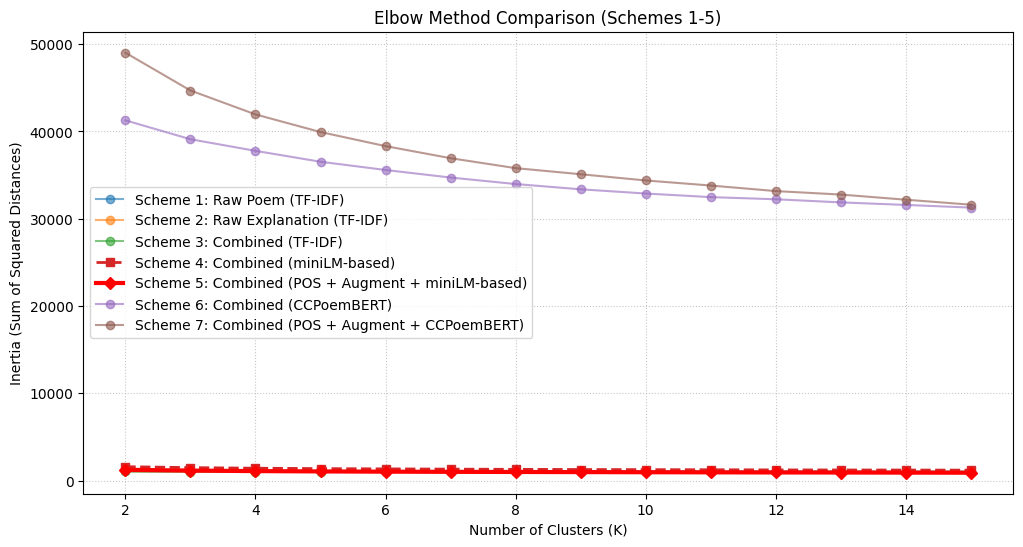

In [ ]:
# 寻找最佳k 方法1：elbow
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. 准备矩阵字典
matrices = {
    "Scheme 1: Raw Poem (TF-IDF)": tfidf_matrix_1,
    "Scheme 2: Raw Explanation (TF-IDF)": tfidf_matrix_2,
    "Scheme 3: Combined (TF-IDF)": tfidf_matrix_3,
    "Scheme 4: Combined (miniLM-based)": tfidf_matrix_4,
    "Scheme 5: Combined (POS + Augment + miniLM-based)": tfidf_matrix_5,
    "Scheme 6: Combined (CCPoemBERT)": tfidf_matrix_6,
    "Scheme 7: Combined (POS + Augment + CCPoemBERT)": tfidf_matrix_7
}

k_range = range(2, 16)
plt.figure(figsize=(12, 6))

print("正在计算全方案的肘部曲线 (Inertia)...")

for label, matrix in matrices.items():
    inertia_list = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        kmeans.fit(matrix)
        inertia_list.append(kmeans.inertia_)

    # 方案 5 使用加粗红线，方案 4 使用虚线以示区分
    if "Scheme 5" in label:
        plt.plot(k_range, inertia_list, marker='D', label=label, linewidth=3, color='red')
    elif "Scheme 4" in label:
        plt.plot(k_range, inertia_list, marker='s', label=label, linewidth=2, linestyle='--')
    else:
        plt.plot(k_range, inertia_list, marker='o', label=label, alpha=0.6)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method Comparison (Schemes 1-5)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

正在计算全方案的轮廓系数 (Silhouette Score)...
⭐ Scheme 1: Raw Poem (TF-IDF) 的最佳 K 值为: 9 (得分: 0.0072)
⭐ Scheme 2: Raw Explanation (TF-IDF) 的最佳 K 值为: 15 (得分: 0.0332)
⭐ Scheme 3: Combined (TF-IDF) 的最佳 K 值为: 14 (得分: 0.0278)
⭐ Scheme 4: Combined (miniLM-based) 的最佳 K 值为: 2 (得分: 0.1555)
⭐ Scheme 5: Combined (POS + Augment + miniLM-based) 的最佳 K 值为: 2 (得分: 0.1684)
⭐ Scheme 6: Combined (CCPoemBERT) 的最佳 K 值为: 2 (得分: 0.0720)


⭐ Scheme 7: Combined (POS + Augment + CCPoemBERT) 的最佳 K 值为: 6 (得分: 0.1389)


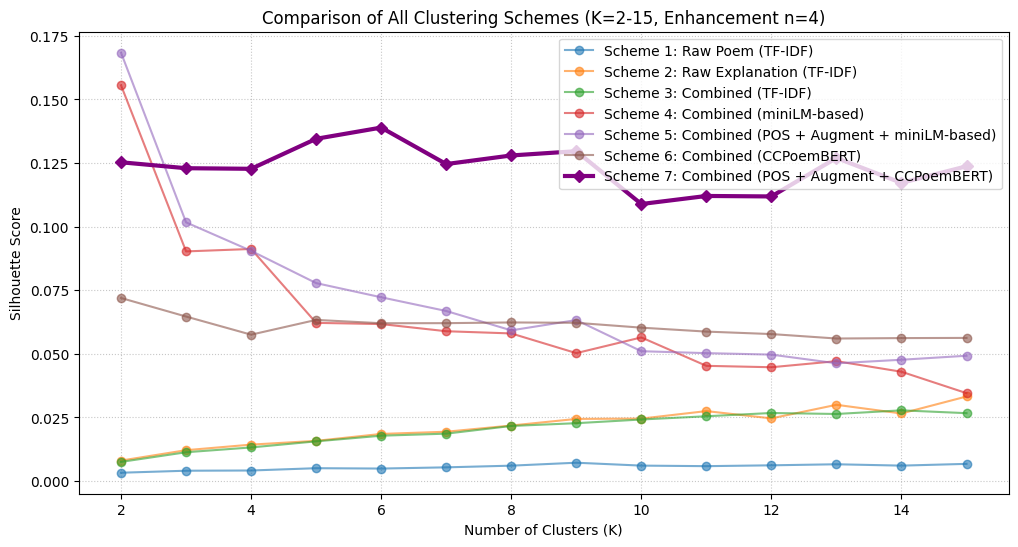

In [ ]:
#寻找最佳k 方案二 轮廓系数
from sklearn.metrics import silhouette_score

plt.figure(figsize=(12, 6))

print("正在计算全方案的轮廓系数 (Silhouette Score)...")

for label, matrix in matrices.items():
    silhouette_avg_list = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        cluster_labels = kmeans.fit_predict(matrix)

        # 计算该 K 值下的轮廓系数
        score = silhouette_score(matrix, cluster_labels)
        silhouette_avg_list.append(score)

    # 方案 7 依然作为重点展示
    if "Scheme 7" in label:
        plt.plot(k_range, silhouette_avg_list, marker='D', label=label, linewidth=3, color='purple')
    else:
        plt.plot(k_range, silhouette_avg_list, marker='o', label=label, alpha=0.6)

    # 打印每个方案的最佳 K 值
    best_k = k_range[silhouette_avg_list.index(max(silhouette_avg_list))]
    print(f"⭐ {label} 的最佳 K 值为: {best_k} (得分: {max(silhouette_avg_list):.4f})")

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title(f'Comparison of All Clustering Schemes (K=2-15, Enhancement n={n})')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


## 选用matrix7 以及 k=7 执行聚类

## 4.1 欧氏距离

In [ ]:
from sklearn.cluster import KMeans
from collections import Counter
import pandas as pd

# 1. 执行最终聚类
final_k = 6
kmeans_final = KMeans(n_clusters=final_k, init='k-means++', n_init=10, random_state=42)
df['final_cluster'] = kmeans_final.fit_predict(tfidf_matrix_7)

# 2. 定义关键词提取函数
def get_cluster_keywords(cluster_id, top_n=8):
    # 针对该簇，从 'enhanced_text' 列提取高频词
    # 这一列是你过滤了词性并加入意境增强后的结果，最能体现聚类逻辑
    cluster_text = " ".join(df[df['final_cluster'] == cluster_id]['enhanced_text'].astype(str))
    words = cluster_text.split()
    # 排除掉可能残留的单字噪音（如果需要）
    common_words = Counter(w for w in words if len(w) > 1).most_common(top_n)
    return [word for word, count in common_words]

# 3. 打印 k 个簇的详细画像
print(f"=== 送花助手：k 大意境场景画像 (Final Result) ===\n")

for i in range(final_k):
    keywords = get_cluster_keywords(i)
    # 从 'poem' 列抽取 3 首代表作展示
    samples = df[df['final_cluster'] == i]['poem'].sample(min(5, len(df[df['final_cluster'] == i]))).values

    print(f"【意境 Cluster {i}】")
    print(f"核心词云: {' / '.join(keywords)}")
    print(f"代表作品: ")
    for s in samples:
        # 清理掉换行符，让输出更整洁
        clean_s = str(s).replace('\n', ' ').strip()
        print(f"  · {clean_s[:50]}...")
    print("-" * 60)

# 4. 可选：保存结果到 CSV，方便之后写报告
# df.to_csv('poem_clustering_results.csv', index=False)

=== 送花助手：k 大意境场景画像 (Final Result) ===

【意境 Cluster 0】
核心词云: 江南 / 秋风 / 清香 / 爱情 / 希望 / 相思 / 高洁 / 寂寞
代表作品: 
  · 荡舟无数伴， 解缆自相催。 汗粉无庸拭， 风裙随意开。 棹移浮荇乱， 船进倚荷来。 藕丝牵作缕， 莲...
  · 新秋菡萏发红英， 向晚风飘满郡馨。 万叠水纹罗乍展， 一只鶒绣初成。 采莲女散吴歌闋， 拾翠人归楚雨...
  · 红云半压秋波碧，艳妆泣露娇啼色。佳梦入仙城，风流石曼卿。 宫袍呼醉醒，休卷西风锦。明日粉香残，六桥烟...
  · 翠云遥拥环妃，夜深按彻霓裳舞。铅华净洗，涓涓出浴，盈盈解语。太液荒寒，海山依约，断魂何许。甚人间、别...
  · 闲吟鲍照赋， 更起屈平愁。 莫引西风动， 红衣不耐秋。...
------------------------------------------------------------
【意境 Cluster 1】
核心词云: 高洁 / 美人 / 清香 / 幽香 / 寂寞 / 江南 / 洁白 / 春色
代表作品: 
  · 清秋湛露浥琼芳， 素影风摇玉砌旁。 夜静看花人独立， 水晶帘外月如霜。...
  · 调冰弄雪，想花神清梦，徘徊南土。一夏天香收不起，付与蕊仙无语。秀入精神，凉生肌骨，销尽人间暑。稼轩愁...
  · 吴兴二赵俱已矣， 雪窗因以专其美。 不须百亩树芳菲， 霜毫扫动光风起。 大花哆唇如笑人， 小花敛眉如...
  · 春才几日，早数枝开遍，笑他红白。仙径曾逢，萼绿华来记相识。修竹天寒翠倚，翻认了，暗侵苔色。 纵一片、...
  · 水月精神玉雪胎，乾坤清气化生来。断桥流水领春回。  昨夜醉眠苔上石，天香冉冉下瑶台。起来窗外见花开。...
------------------------------------------------------------
【意境 Cluster 2】
核心词云: 美丽 / 艳丽 / 娇艳 / 寂寞 / 美人 / 含蓄 / 春色 / 希望
代表作品: 
  · 宫云朵朵映朝霞， 百宝栏前斗丽华。 卯酒未消红玉面， 薄施檀粉伴梅花。洛阳女儿红颜饶， 血色罗裙宝抹...
  · 借暖冲寒不用媒， 匀朱匀粉最先来。 玉梅一见怜痴小， 教向旁边自在开。..

正在使用 t-SNE 进行降维处理（这可能需要几十秒）...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


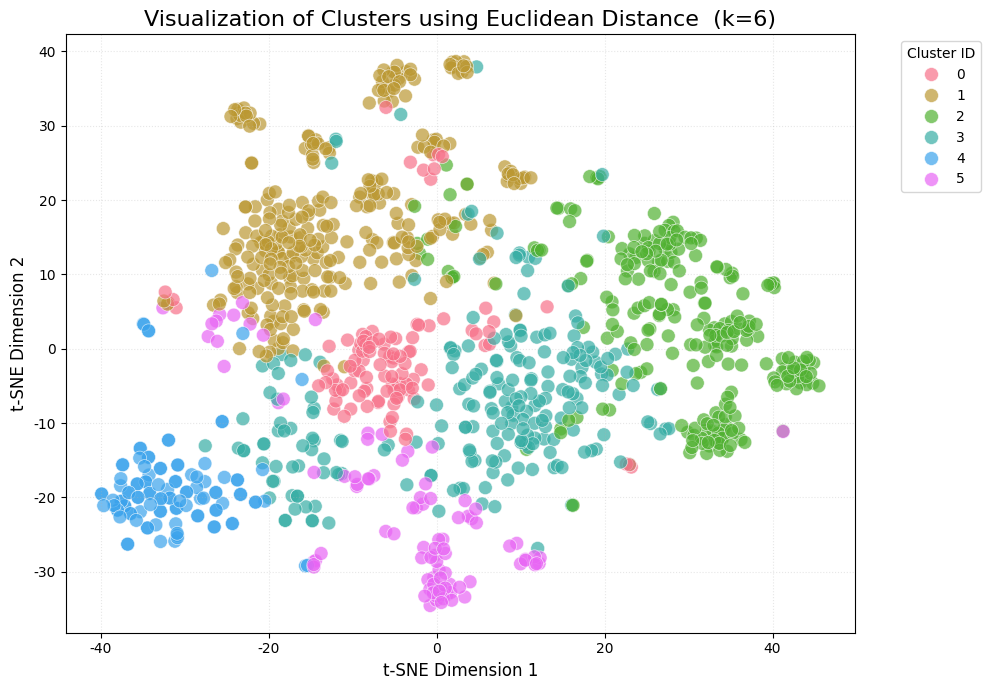

In [ ]:
# 欧氏距离 t-SNE 可视化

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np

# 1. 降维处理：适配 NumPy 数组格式
print("正在使用 t-SNE 进行降维处理（这可能需要几十秒）...")

# 检查矩阵格式并自动处理
if hasattr(tfidf_matrix_7, "toarray"):
    data_for_tsne = tfidf_matrix_7.toarray()
else:
    data_for_tsne = tfidf_matrix_7

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
reduced_data = tsne.fit_transform(data_for_tsne)

# 2. 准备绘图 DataFrame
vis_df = pd.DataFrame(reduced_data, columns=['x', 'y'])
vis_df['cluster'] = df['final_cluster']

# 3. 设置字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 4. 绘图
plt.figure(figsize=(10, 7), dpi=100)
# 使用更加柔和且区分度高的颜色
palette = sns.color_palette("husl", n_colors=final_k)

sns.scatterplot(
    x='x', y='y',
    hue='cluster',
    data=vis_df,
    palette=palette,
    legend='full',
    alpha=0.7,
    s=100,      # 稍微调大一点点，看起来更丰满
    edgecolor='w',
    linewidth=0.5
)

# 5. 装饰美化
plt.title(f'Visualization of Clusters using Euclidean Distance  (k={final_k})', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

## 4.2 余弦夹角

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from collections import Counter
import pandas as pd

# 1. 执行 L2 归一化
tfidf_norm = normalize(tfidf_matrix_7)

final_k = 6
kmeans_final = KMeans(n_clusters=final_k, init='k-means++', n_init=10, random_state=42)
df['final_cluster'] = kmeans_final.fit_predict(tfidf_norm)
#-- 保存文件 --
centroids = kmeans_final.cluster_centers_
np.save('/content/drive/MyDrive/Colab Notebooks/5572 flower/cluster_centroids.npy', centroids)
joblib.dump(kmeans, '/content/drive/MyDrive/Colab Notebooks/5572 flower/kmeans_model.pkl')

# --- 💡 新增：保存文件到指定路径 ---
save_path = '/content/drive/MyDrive/Colab Notebooks/5572 flower/final_results.csv'
df.to_csv(save_path, index=False)
print(f"✅ 包含聚类标签的数据已保存至: {save_path}")
# -------------------------------

# 2. 定义关键词提取函数 (保持不变)
def get_cluster_keywords(cluster_id, top_n=8):
    cluster_text = " ".join(df[df['final_cluster'] == cluster_id]['enhanced_text'].astype(str))
    words = cluster_text.split()
    common_words = Counter(w for w in words if len(w) > 1).most_common(top_n)
    return [word for word, count in common_words]

# 3. 打印详细画像
print(f"=== 数字人文视角：基于余弦相似度的意境聚类 ===\n")

for i in range(final_k):
    keywords = get_cluster_keywords(i)
    # 修正：这里使用 final_cluster 匹配
    current_cluster_df = df[df['final_cluster'] == i]
    samples = current_cluster_df['poem'].sample(min(3, len(current_cluster_df))).values

    print(f"【意境场景 Cluster {i}】")
    print(f"核心意象: {' | '.join(keywords)}")
    print(f"代表性文本切片: ")
    for s in samples:
        clean_s = str(s).replace('\n', ' ').strip()
        print(f"  · {clean_s[:50]}...")
    print("-" * 60)

✅ 包含聚类标签的数据已保存至: /content/drive/MyDrive/Colab Notebooks/5572 flower/final_results.csv
=== 数字人文视角：基于余弦相似度的意境聚类 ===

【意境场景 Cluster 0】
核心意象: 含蓄 | 寂寞 | 冷落 | 高洁 | 独特 | 顽强 | 萧瑟 | 秋风
代表性文本切片: 
  · 芳菲过眼已成空， 寂寞篱边见几丛。 颜色只从霜后好， 不知人世有春风。...
  · 陶令黄金绕舍， 君家白玉满园。 千古清风庐阜， 几丛细雨江门。...
  · 野菊亭亭争秀，闲伴露荷风柳。浅碧小开花，谁摘、谁看、谁嗅？知否，知否？不入东篱杯酒。...
------------------------------------------------------------
【意境场景 Cluster 1】
核心意象: 幽香 | 高洁 | 寂寞 | 清香 | 美人 | 春色 | 相思 | 凄凉
代表性文本切片: 
  · 荔枝乡里玲珑雪， 来助长安一夏凉。 情味于人最浓处， 梦回犹觉鬓旁香。...
  · 苔枝缀玉，有翠禽小小，枝上同宿。客里相逢，篱角黄昏，无言自倚修竹。昭君不惯胡沙远，但暗忆、江南江北。...
  · 槿篱芳楦近樵家， 垅麦青青一径斜。 寂寞游人寒食后， 夜来风雨送梨花。...
------------------------------------------------------------
【意境场景 Cluster 2】
核心意象: 凄凉 | 希望 | 春色 | 寂寞 | 多情 | 江南 | 飘零 | 哀怨
代表性文本切片: 
  · 人间跌宕简斋老， 天下风流月桂花。 一壶不觉丛边尽， 暮雨霏霏欲湿鸦。...
  · 阳春二三月， 杨柳齐作花。 春风一夜入闺阙， 杨花飘荡落南家。 含情出户脚无力， 拾得杨花泪沾臆。 ...
  · 游弥牟菩提院，庭下有凌霄，藤附古楠，其高数丈，花已零落委地。 绛英翠蔓亦佳哉， 零乱空庭玛瑙杯。 遍...
------------------------------------------------------------
【意境场景 Cluster 3】
核心意象: 高洁 | 江南 | 清香 | 美人 | 憔悴 | 美丽 | 爱

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_3652/1161474886.py:52: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3652/1161474886.py:52: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


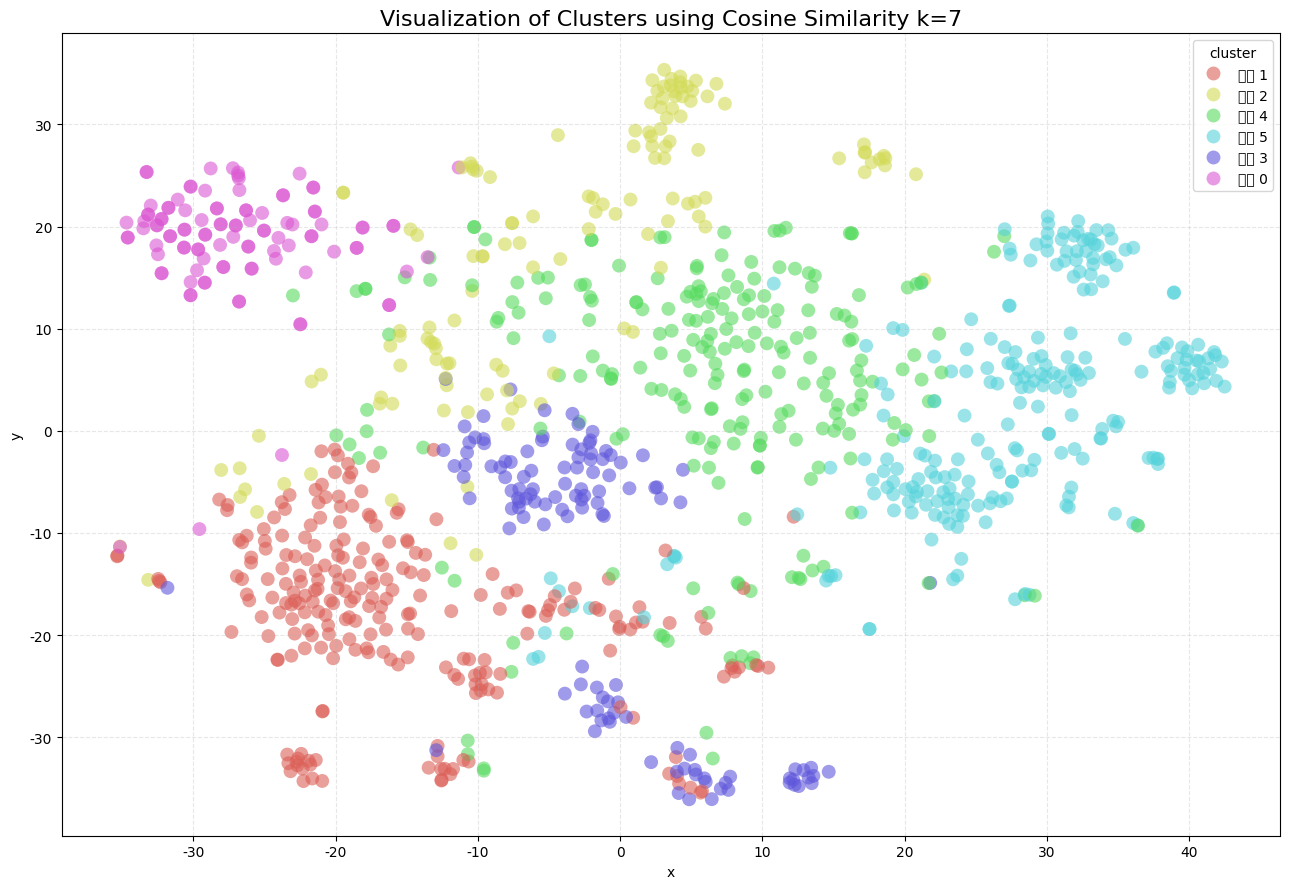

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 环境配置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 检查并转换数据格式
# 因为之前的 normalize(tfidf_matrix_7) 已经返回了 numpy.ndarray
# 所以这里直接使用，不再调用 .toarray()
data_to_embed = tfidf_norm

# 3. 执行 t-SNE 降维
# n_iter 增加迭代次数可以让聚类更紧凑，利于展示
tsne = TSNE(n_components=2, perplexity=30, init='pca', n_iter=1000, random_state=42)
tfidf_embedded = tsne.fit_transform(data_to_embed)

# 4. 构建可视化 DataFrame
df_tsne = pd.DataFrame({
    'x': tfidf_embedded[:, 0],
    'y': tfidf_embedded[:, 1],
    'cluster': df['final_cluster'].map(lambda x: f"意境 {x}") # 增加易读性
})

# 5. 绘制散点图
plt.figure(figsize=(13, 9))
palette = sns.color_palette("hls", final_k) # 使用高对比度配色

scatter = sns.scatterplot(
    data=df_tsne,
    x='x', y='y',
    hue='cluster',
    palette=palette,
    alpha=0.6,
    s=100,
    edgecolor='none'
)

# 6. 计算并标注每个聚类的中心点 (增加演示的专业度)
for i in range(final_k):
    cluster_label = f"cluster {i}"
    center = df_tsne[df_tsne['cluster'] == cluster_label][['x', 'y']].mean()
    plt.text(center['x'], center['y'], cluster_label,
             fontsize=14, weight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.title('Visualization of Clusters using Cosine Similarity k=7', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 加载后立即检查
centroids = np.load("/content/drive/MyDrive/Colab Notebooks/5572 flower/cluster_centroids.npy")
print(f"!!! 聚类中心数量: {centroids.shape[0]}")

!!! 聚类中心数量: 6
